In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

#Carrega o dicionário
try:
    with open('/home/bruno/UESC/DataSUS/DadosTUB/src/dicionario_sinan_tuberculose.json', 'r', encoding='utf-8') as f:
        dicionario = json.load(f)
except FileNotFoundError:
    print("Dicionário não encontrado.")

df = pd.read_csv('/home/bruno/UESC/DataSUS/DadosTUB/data/processed/tuberculose_ilheus_itabuna_final.csv')
colunas_data = [col for col in df.columns if 'Data' in col]
for col in colunas_data:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(f"Dataset carregado: {df.shape[0]} registros e {df.shape[1]} colunas.")
df.head()

Dataset carregado: 3430 registros e 75 colunas.


,Tipo_Notificacao,Agravo_Codigo,Data_Notificacao,Ano_Notificacao,UF_Notificacao,Municipio_Notificacao,Regional_Notificacao,Data_Diagnostico,Ano_Nascimento,Sexo,...,Agravo_Tabagismo,Teste_Rapido_Molecular,Teste_Sensibilidade,Uso_Antiretroviral,Baciloscopia_Apos_6_Meses,Transferencia_Confirmada,UF_Transferencia,Municipio_Transferencia,Idade_Anos,Dias_Ate_Encerramento
0,2,A169,2015-12-04,2015,29,291360,1385,2015-12-03,1958.0,Feminino,...,2.0,5.0,7.0,0.0,0.0,0.0,NaN,NaN,57,186.0
1,2,A169,2015-12-04,2015,29,291360,1385,2015-12-04,1945.0,Feminino,...,2.0,5.0,5.0,0.0,0.0,0.0,NaN,NaN,70,214.0
2,2,A169,2015-12-23,2015,29,291480,1386,2015-12-05,1981.0,Masculino,...,1.0,5.0,0.0,0.0,0.0,0.0,NaN,NaN,34,205.0
3,2,A169,2015-12-07,2015,29,291360,1385,2015-12-07,1961.0,Masculino,...,1.0,5.0,5.0,0.0,0.0,0.0,NaN,NaN,54,192.0
4,2,A169,2015-12-07,2015,29,291360,1385,2015-12-07,1985.0,Masculino,...,2.0,5.0,0.0,0.0,0.0,0.0,NaN,NaN,30,219.0


Para continuar nossa análise vamos verificar agora correlações sociodemográficas nos dados, como vimos na última análise, os alvos mais afetados pela Tuberculose são homens em idade comercial (20 à 49 anos), logo devemos perfilar essas pessoas para entendermos de forma mais profunda a fonte do problema.

Em primeira análise vamos entender a relação da infecção pela tuberculose com a cor e escolaridade das pessoas afetadas.

/tmp/ipykernel_4683/211154608.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_demo_raca,
/tmp/ipykernel_4683/211154608.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_demo_esc,


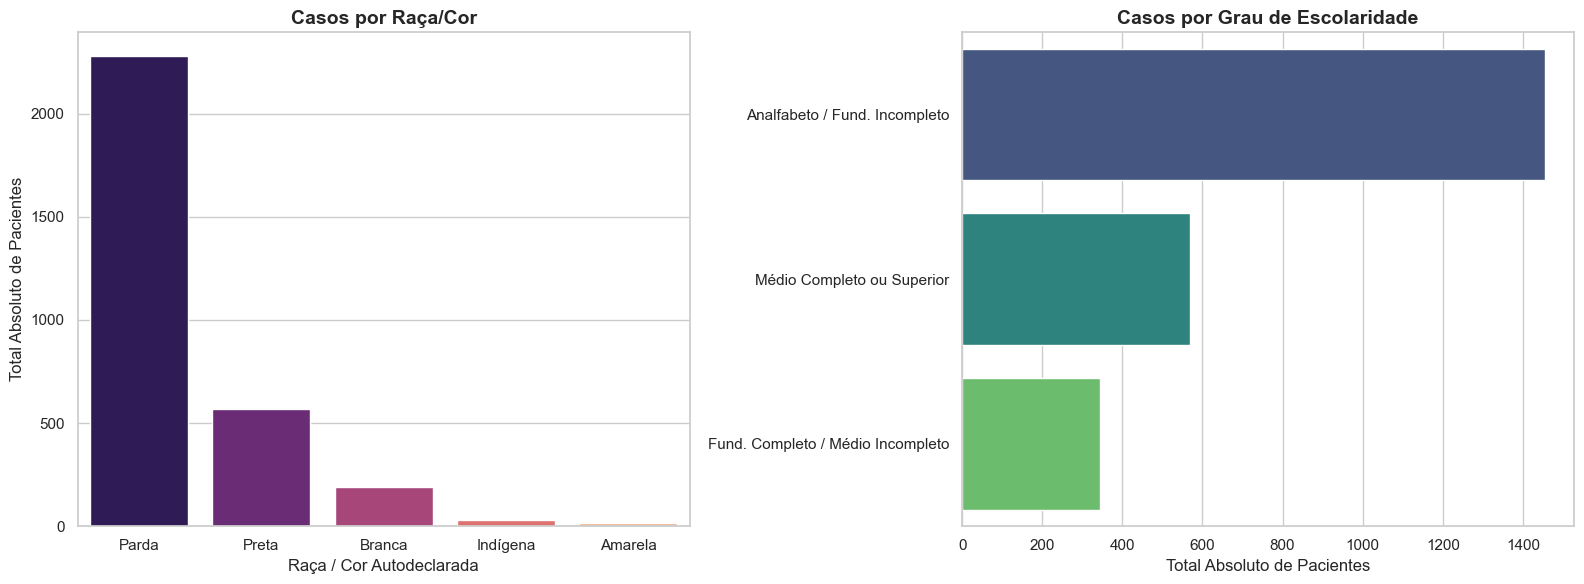

In [5]:
df_demo = df.copy()

# Mapeamento de Raça/Cor
mapa_raca = {1.0: 'Branca', 2.0: 'Preta', 3.0: 'Amarela', 4.0: 'Parda', 5.0: 'Indígena'}
df_demo['Perfil_Raca'] = df_demo['Raca_Cor'].map(mapa_raca)

# Mapeamento de Escolaridade
def classificar_escolaridade(codigo):
    if pd.isna(codigo) or codigo == 9.0: return 'Não Informado'
    elif codigo in [0.0, 1.0, 2.0, 3.0]: return 'Analfabeto / Fund. Incompleto'
    elif codigo in [4.0, 5.0]: return 'Fund. Completo / Médio Incompleto'
    elif codigo in [6.0, 7.0, 8.0]: return 'Médio Completo ou Superior'
    else: return 'Não Informado'

df_demo['Perfil_Escolaridade'] = df_demo['Escolaridade'].apply(classificar_escolaridade)
df_demo_raca = df_demo.dropna(subset=['Perfil_Raca'])
df_demo_esc = df_demo[df_demo['Perfil_Escolaridade'] != 'Não Informado']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#GRÁFICO 1
sns.countplot(data=df_demo_raca, 
              x='Perfil_Raca', 
              palette='magma', 
              order=df_demo_raca['Perfil_Raca'].value_counts().index, 
              ax=axes[0])
axes[0].set_title('Casos por Raça/Cor', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Raça / Cor Autodeclarada')
axes[0].set_ylabel('Total Absoluto de Pacientes')

#GRÁFICO 2
sns.countplot(data=df_demo_esc, 
              y='Perfil_Escolaridade', 
              palette='viridis', 
              order=df_demo_esc['Perfil_Escolaridade'].value_counts().index, 
              ax=axes[1])
axes[1].set_title('Casos por Grau de Escolaridade', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Absoluto de Pacientes')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

A partir destes resultados traçamos o perfil da Tuberculose em Ilhéus e Itabuna: Em grande maioria são homens adultos (em idade laboral), pardos, analfabetos/Ensino Fundamental incompleto e suscetibilidade ao alcoolismo. 

Isto prova matematicamente que a bactéria da tuberculose não escolhe as suas vítimas de forma aleatória. Ela prospera na vulnerabilidade social, em trabalhos precários (onde a pessoa não pode faltar 6 meses para se tratar) e em condições habitacionais mais frágeis.

Dessa forma, para seguir nossa análise vamos tentar entender como essas pessoas passam pelo tratamento, pessoas que não tem a possibilidade de realizar o tratamento em suma completude, seja pela impossibilidade de parar de trabalhar ou não interromper o consumo de álcool tem maior tendência à abandonar o processo e reingressar em algum momento.

/tmp/ipykernel_4683/917592721.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_entrada,


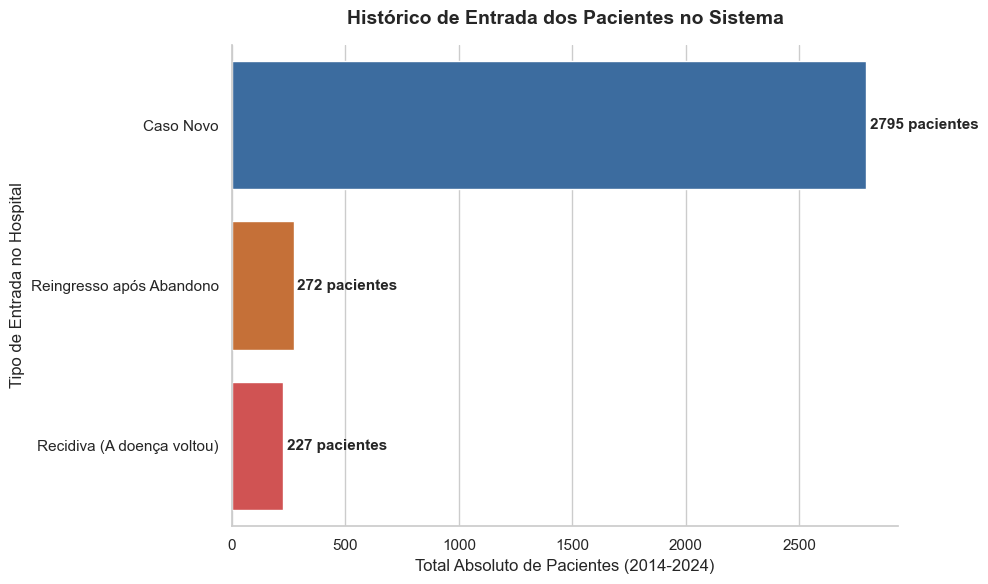

In [9]:
df_entrada = df.copy()
mapa_entrada = {
    1.0: 'Caso Novo',
    2.0: 'Recidiva (A doença voltou)',
    3.0: 'Reingresso após Abandono',
    4.0: 'Não Sabe',
    5.0: 'Transferência',
    6.0: 'Pós-Óbito'
}

# Tradução direta
df_entrada['Perfil_Entrada'] = df_entrada['Tipo_Entrada'].map(mapa_entrada)
categorias_alvo = ['Caso Novo', 'Recidiva (A doença voltou)', 'Reingresso após Abandono']
df_entrada = df_entrada[df_entrada['Perfil_Entrada'].isin(categorias_alvo)]
plt.figure(figsize=(10, 6))
sns.countplot(data=df_entrada, 
              y='Perfil_Entrada', 
              palette=['#2b6cb0', '#dd6b20', '#e53e3e'],
              order=df_entrada['Perfil_Entrada'].value_counts().index)
plt.title('Histórico de Entrada dos Pacientes no Sistema', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Absoluto de Pacientes (2014-2024)', fontsize=12)
plt.ylabel('Tipo de Entrada no Hospital', fontsize=12)

for p in plt.gca().patches:
    largura = p.get_width()
    plt.text(largura + 15, p.get_y() + p.get_height()/2, 
             f'{int(largura)} pacientes', va='center', ha='left', fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()

plt.show()

A soma de 449 pacientes representa quase 15% de todos os casos registrados em Ilhéus e Itabuna, essas provavelmente são as pessoas presas no ciclo de incapacidade de completar o tratamento. O Sistema Único de Saúde (SUS) gasta tempo, dinheiro e medicamentos com pacientes e não consegue cura-los definitivamente, e eles voltam a adoecer e trasmitir a bactério gerando um efeito "bola de neve".

Os dados do SINAN contam com a coluna de TDO, que se trata do tratamento supervisionado, que pode ser a melhor opção nesses casos de pessoas com menor possibilidade de concluir o tratamento sozinhos. Vamos analisar a porcentagem de sucesso em ambos os casos.

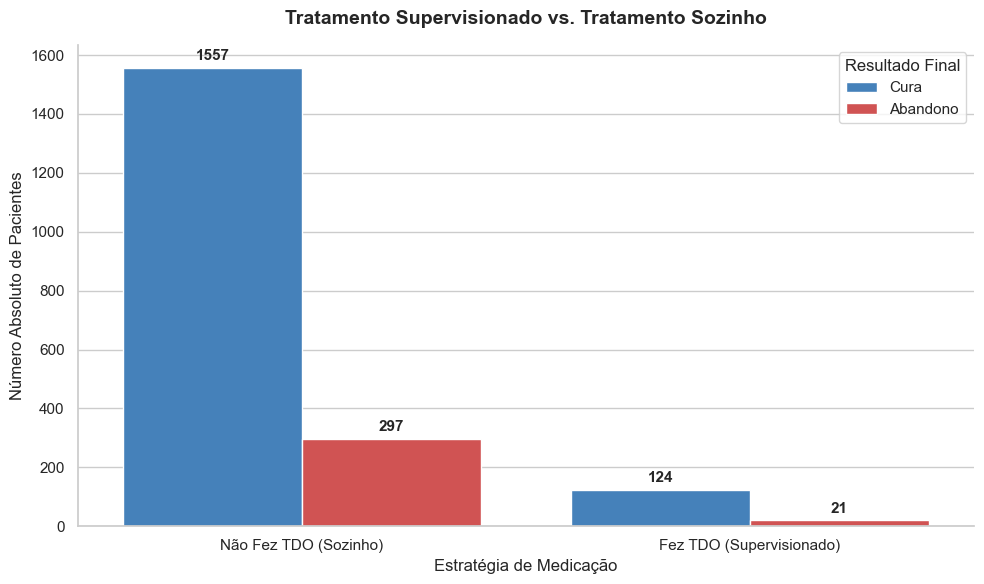

In [13]:
df_tdo = df.copy()

df_tdo = df_tdo[df_tdo['Situacao_Encerramento_Final'].isin([1.0, 2.0])]
df_tdo['Desfecho'] = df_tdo['Situacao_Encerramento_Final'].map({1.0: 'Cura', 2.0: 'Abandono'})
df_tdo = df_tdo[df_tdo['Tratamento_Supervisionado_Atual'].isin([1.0, 2.0])]
df_tdo['Politica_TDO'] = df_tdo['Tratamento_Supervisionado_Atual'].map({
    1.0: 'Fez TDO (Supervisionado)', 
    2.0: 'Não Fez TDO (Sozinho)'
})

plt.figure(figsize=(10, 6))

sns.countplot(data=df_tdo, 
              x='Politica_TDO', 
              hue='Desfecho', 
              palette=['#3182ce', '#e53e3e'])
plt.title('Tratamento Supervisionado vs. Tratamento Sozinho', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Estratégia de Medicação', fontsize=12)
plt.ylabel('Número Absoluto de Pacientes', fontsize=12)

for p in plt.gca().patches:
    altura = p.get_height()
    if altura > 0:
        plt.text(p.get_x() + p.get_width()/2., altura + 15, 
                 f'{int(altura)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.legend(title='Resultado Final')
sns.despine()
plt.tight_layout()

plt.show()

Apesar da queda na taxa de abandono em casos de tratamento supervisionado (1,6%) vemos que apenas 8% dos agravos de tuberculose em Ilhéus e Itabuna recebem essa contenção de abandono, o que pode representar uma baixa capacidade do sistema municipal de saúde no tratamento de tuberculose.

Ainda na análise da eficácia do sistema de saúde municipal de Ilhéus e Itabuna vamos correlacionar o tempo entre o diagnóstico com o de início do tratamento, pelo fato da Tuberculose ser um agravo de fácil trasmissão, esse período pode ser um ponto de complicação para os números de casos de Tuberculose nas cidades.

/tmp/ipykernel_4683/3247153144.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_tempo,


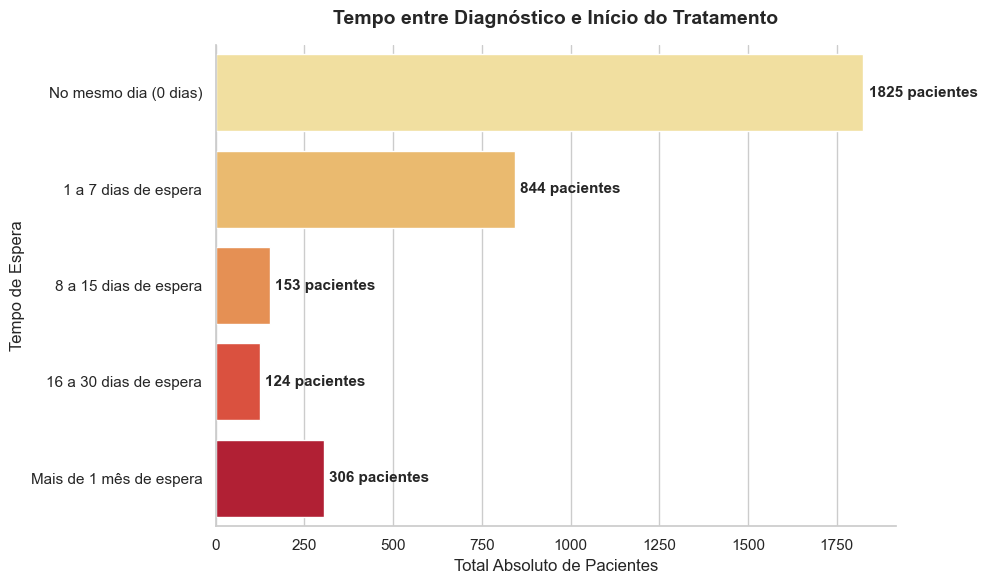

In [12]:
df_tempo = df.copy()

df_tempo['Data_Diagnostico'] = pd.to_datetime(df_tempo['Data_Diagnostico'], errors='coerce')
df_tempo['Data_Inicio_Tratamento'] = pd.to_datetime(df_tempo['Data_Inicio_Tratamento'], errors='coerce')
df_tempo['Dias_Atraso'] = (df_tempo['Data_Inicio_Tratamento'] - df_tempo['Data_Diagnostico']).dt.days
df_tempo = df_tempo[(df_tempo['Dias_Atraso'] >= 0) & (df_tempo['Dias_Atraso'] <= 180)].copy()

def categorizar_espera(dias):
    if dias == 0: return 'No mesmo dia (0 dias)'
    elif dias <= 7: return '1 a 7 dias de espera'
    elif dias <= 15: return '8 a 15 dias de espera'
    elif dias <= 30: return '16 a 30 dias de espera'
    else: return 'Mais de 1 mês de espera'

df_tempo['Perfil_Espera'] = df_tempo['Dias_Atraso'].apply(categorizar_espera)
ordem_tempo = [
    'No mesmo dia (0 dias)', 
    '1 a 7 dias de espera', 
    '8 a 15 dias de espera', 
    '16 a 30 dias de espera', 
    'Mais de 1 mês de espera'
]

plt.figure(figsize=(10, 6))
sns.countplot(data=df_tempo, 
              y='Perfil_Espera', 
              order=ordem_tempo, 
              palette='YlOrRd')
plt.title('Tempo entre Diagnóstico e Início do Tratamento', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Absoluto de Pacientes', fontsize=12)
plt.ylabel('Tempo de Espera', fontsize=12)
for p in plt.gca().patches:
    largura = p.get_width()
    plt.text(largura + 15, p.get_y() + p.get_height()/2, 
             f'{int(largura)} pacientes', va='center', ha='left', fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()

plt.show()

De forma majoritária (2680 pacientes que represetam mais de 80% dos casos) o sistema é eficaz e inicia o tratamento dentro da primeira semana de diagnóstico, porém o dado de 306 pessoas que precisaram esperar mais de 30 dias para iniciar seu tratamento é o maior indicativo para a contínua circulação da bactéria na região.

Apesar dos dados do SINAN não possuir informações sobre Bairro, CEP ou Lougradouro para realizarmos uma análise geoespacial para mapearmos as localizações de maior vunerabilidade, temos acesso a informação se os pacientes possuem moradia, dessa forma vamos analisar a relação das pessoas em situação de rua com o agravo da Tuberculose.

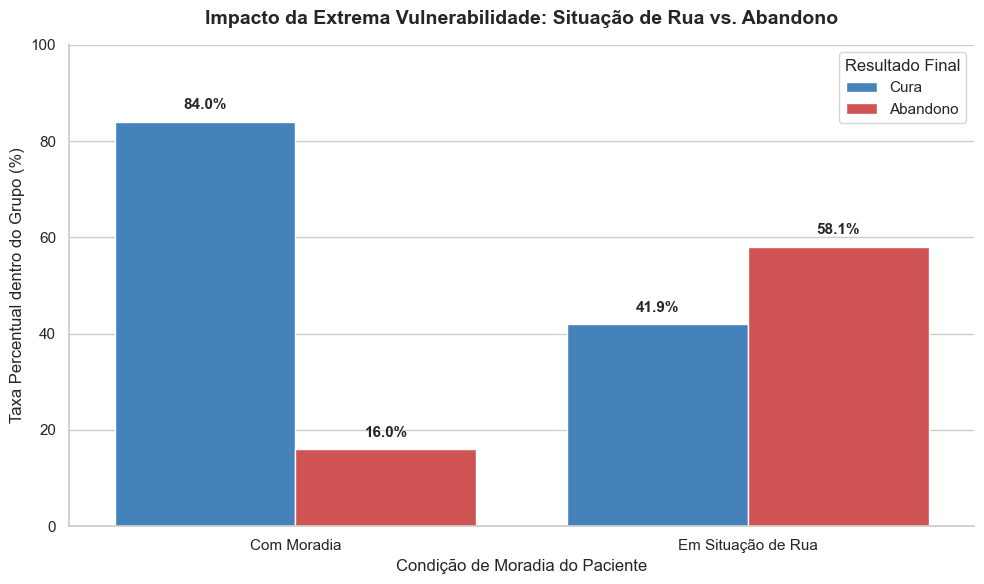

In [14]:
df_rua = df.copy()

df_rua = df_rua[df_rua['Situacao_Encerramento_Final'].isin([1.0, 2.0])]
df_rua['Desfecho'] = df_rua['Situacao_Encerramento_Final'].map({1.0: 'Cura', 2.0: 'Abandono'})
df_rua = df_rua[df_rua['Populacao_Situacao_Rua'].isin([1.0, 2.0])]
df_rua['Condicao_Moradia'] = df_rua['Populacao_Situacao_Rua'].map({
    1.0: 'Em Situação de Rua', 
    2.0: 'Com Moradia'
})

proporcoes_rua = df_rua.groupby('Condicao_Moradia')['Desfecho'].value_counts(normalize=True).rename('Proporcao').reset_index()
proporcoes_rua['Porcentagem (%)'] = proporcoes_rua['Proporcao'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(data=proporcoes_rua, 
            x='Condicao_Moradia', 
            y='Porcentagem (%)', 
            hue='Desfecho', 
            palette=['#3182ce', '#e53e3e'])
plt.title('Impacto da Extrema Vulnerabilidade: Situação de Rua vs. Abandono', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Condição de Moradia do Paciente', fontsize=12)
plt.ylabel('Taxa Percentual dentro do Grupo (%)', fontsize=12)
plt.ylim(0, 100) 
for p in plt.gca().patches:
    altura = p.get_height()
    if altura > 0:
        plt.text(p.get_x() + p.get_width()/2., altura + 2, 
                 f'{altura:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.legend(title='Resultado Final')
sns.despine()
plt.tight_layout()

plt.show()

Os números mostram que a taxa de cura é cortada pela metade para pessoas em situação de rua.